In [1]:
#Ativando pacotes
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyproj
from PIL import Image

1. Criar um mapa coroplético para o total de casos de COVID-19 acumulados por 100.000 habitantes até o dia 08/12/2021 para os municípios do Estado do Rio de Janeiro.
• Sahpefile: Shape_Estado_RJ.zip.
• Base de dados: Casos_Mortes_RJ.csv.
• Chave: código do município (7 dígitos).

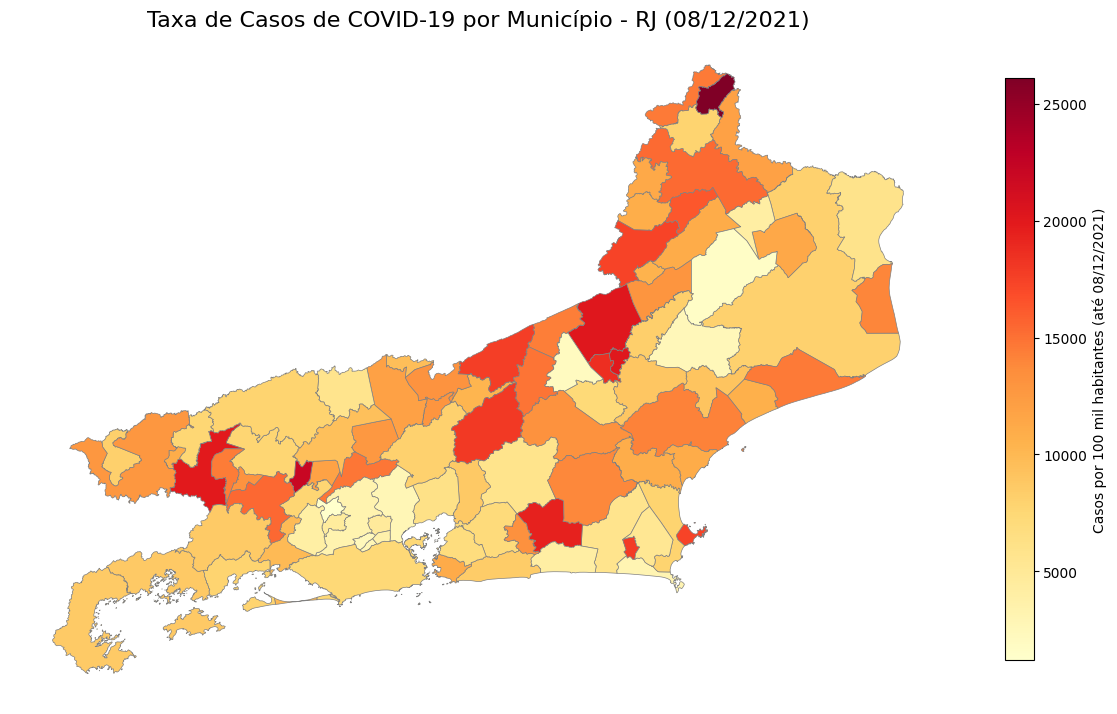

In [2]:
# Importando o shapefile do Estado do RJ
RJshp = gpd.read_file("Shape_Estado_RJ.zip")
RJshp['CD_GEOCMU'] = RJshp['CD_GEOCMU'].astype('int64')

# Importando base de dados
dados_mortes = pd.read_csv("Casos_Mortes_RJ.csv", sep=";", decimal=",")

# Selecionando os dados da data especificada
dados_mortes_08dez = dados_mortes[dados_mortes.date == '08/12/2021']

# Merge entre o shapefile e os dados
RJ_Covid_merge = pd.merge(
    left=RJshp,
    right=dados_mortes_08dez,
    left_on="CD_GEOCMU",
    right_on="ibgeID",
    how="left"
)

# Plotando o gráfico com melhorias visuais
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
RJ_Covid_merge.plot(
    column="totalCases100k",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="gray",
    ax=ax,
    legend=True,
    legend_kwds={
        "shrink": 0.6,
        "label": "Casos por 100 mil habitantes (até 08/12/2021)",
        "orientation": "vertical"
    }
)

# Título e estética
ax.set_title("Taxa de Casos de COVID-19 por Município - RJ (08/12/2021)", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

2) Criar um mapa coroplético para o total de revólveres apreendidos no ano de 2019 para as RISP do Estado do Rio de Janeiro.

• Sahpefile: RISP RJ.zip

• Base de dados: ArmasApreendidasEvolucaoCisp.csv

• Chave: código da RISP.

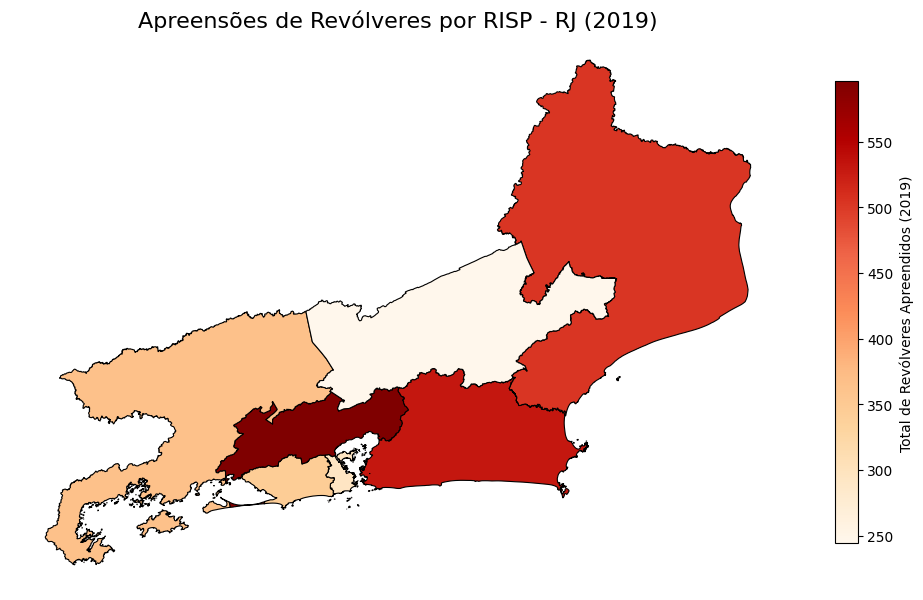

In [3]:
# Importando o shapefile das RISP-RJ
RISPshp = gpd.read_file("RISP RJ.zip")
RISPshp['risp'] = RISPshp['risp'].astype('int64')

# Importando a base de dados
dados_armas = pd.read_csv("ArmasApreendidasEvolucaoCisp.csv", sep=";", decimal=",")

# Filtro para as ocorrências no ano de 2019
dados_armas_2019 = dados_armas[dados_armas.ano == 2019]

# Consolidado de ocorrências em 2019 por RISP
dados_armas_2019_risp = dados_armas_2019.groupby("risp", sort=True).agg(
    total_revolver=pd.NamedAgg(column="arma_fogo_revolver", aggfunc="sum")
)
dados_armas_2019_risp['RISP'] = dados_armas_2019_risp.index

# Merge do shapefile e da base de dados
RJ_Covid_merge = pd.merge(
    RISPshp,
    dados_armas_2019_risp,
    left_on="risp",
    right_on="RISP",
    how="left"
)

# Plotando o gráfico com melhorias visuais
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
RJ_Covid_merge.plot(
    column="total_revolver",
    cmap="OrRd",
    linewidth=0.8,
    ax=ax,
    edgecolor="black",
    legend=True,
    legend_kwds={"shrink": 0.6, "label": "Total de Revólveres Apreendidos (2019)", "orientation": "vertical"}
)

# Título e remoção dos eixos
ax.set_title("Apreensões de Revólveres por RISP - RJ (2019)", fontsize=16)
ax.set_axis_off()

# Mostrar o gráfico
plt.tight_layout()
plt.show()